# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- **Use Pandas to load, inspect, and clean the dataset appropriately.**
- **Transform relevant columns to create measures that address the problem at hand.**
- conduct EDA: visualization and statistical measures to systematically understand the structure of the data
- recommend a set of airplanes and makes conforming to the client's request and identify at least *two* factors contributing to airplane safety. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.

### Make relevant library imports

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading and Inspection

### Load in data from the relevant directory and inspect the dataframe.
- inspect NaNs, datatypes, and summary statistics

In [21]:
df = pd.read_csv('data/AviationData.csv', encoding="latin1", low_memory=False)
df.head(3)

,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007


In [39]:
df.shape
print(f" The dataframe has {df.shape[0]} rows and {df.shape[1]} columns")

 The dataframe has 88889 rows and 31 columns


In [27]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  Make                    88826 non-null

In [31]:
df.columns

Index(['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date',
       'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code',
       'Airport.Name', 'Injury.Severity', 'Aircraft.damage',
       'Aircraft.Category', 'Registration.Number', 'Make', 'Model',
       'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description',
       'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries',
       'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured',
       'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status',
       'Publication.Date'],
      dtype='object')

In [33]:
df.isnull().sum().sort_values(ascending=False)

Schedule                  76307
Air.carrier               72241
FAR.Description           56866
Aircraft.Category         56602
Longitude                 54516
Latitude                  54507
Airport.Code              38757
Airport.Name              36185
Broad.phase.of.flight     27165
Publication.Date          13771
Total.Serious.Injuries    12510
Total.Minor.Injuries      11933
Total.Fatal.Injuries      11401
Engine.Type                7096
Report.Status              6384
Purpose.of.flight          6192
Number.of.Engines          6084
Total.Uninjured            5912
Weather.Condition          4492
Aircraft.damage            3194
Registration.Number        1382
Injury.Severity            1000
Country                     226
Amateur.Built               102
Model                        92
Make                         63
Location                     52
Investigation.Type            0
Event.Date                    0
Accident.Number               0
Event.Id                      0
dtype: i

In [35]:
df.dtypes

Event.Id                   object
Investigation.Type         object
Accident.Number            object
Event.Date                 object
Location                   object
Country                    object
Latitude                   object
Longitude                  object
Airport.Code               object
Airport.Name               object
Injury.Severity            object
Aircraft.damage            object
Aircraft.Category          object
Registration.Number        object
Make                       object
Model                      object
Amateur.Built              object
Number.of.Engines         float64
Engine.Type                object
FAR.Description            object
Schedule                   object
Purpose.of.flight          object
Air.carrier                object
Total.Fatal.Injuries      float64
Total.Serious.Injuries    float64
Total.Minor.Injuries      float64
Total.Uninjured           float64
Weather.Condition          object
Broad.phase.of.flight      object
Report.Status 

In [48]:

print(df.describe())
print("\n Categorical summary \n\n")
print(df.describe(include=['O']))

       Number.of.Engines  Total.Fatal.Injuries  Total.Serious.Injuries  \
count       82805.000000          77488.000000            76379.000000   
mean            1.146585              0.647855                0.279881   
std             0.446510              5.485960                1.544084   
min             0.000000              0.000000                0.000000   
25%             1.000000              0.000000                0.000000   
50%             1.000000              0.000000                0.000000   
75%             1.000000              0.000000                0.000000   
max             8.000000            349.000000              161.000000   

       Total.Minor.Injuries  Total.Uninjured  
count          76956.000000     82977.000000  
mean               0.357061         5.325440  
std                2.235625        27.913634  
min                0.000000         0.000000  
25%                0.000000         0.000000  
50%                0.000000         1.000000  
75% 

## Data Cleaning

### Filtering aircrafts and events

We want to filter the dataset to include aircraft that the client is interested in an analysis of:
- inspect relevant columns
- figure out any reasonable imputations
- filter the dataset

In [49]:
df.columns = df.columns.str.replace(" ","_", regex = True).str.lower().str.strip()
df[:5]

,event.id,investigation.type,accident.number,event.date,location,country,latitude,longitude,airport.code,airport.name,...,purpose.of.flight,air.carrier,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured,weather.condition,broad.phase.of.flight,report.status,publication.date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007
3,20001218X45448,Accident,LAX96LA321,1977-06-19,"EUREKA, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,IMC,Cruise,Probable Cause,12-09-2000
4,20041105X01764,Accident,CHI79FA064,1979-08-02,"Canton, OH",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,1.0,2.0,NaN,0.0,VMC,Approach,Probable Cause,16-04-1980


In [56]:
for coln in df.columns:
    uni_val = df[coln].unique()
    print(f" {coln}\n {uni_val}\n \n")

 event.id
 ['20001218X45444' '20001218X45447' '20061025X01555' ... '20221227106497'
 '20221227106498' '20221230106513']
 

 investigation.type
 ['Accident' 'Incident']
 

 accident.number
 ['SEA87LA080' 'LAX94LA336' 'NYC07LA005' ... 'WPR23LA075' 'WPR23LA076'
 'ERA23LA097']
 

 event.date
 ['1948-10-24' '1962-07-19' '1974-08-30' ... '2022-12-22' '2022-12-26'
 '2022-12-29']
 

 location
 ['MOOSE CREEK, ID' 'BRIDGEPORT, CA' 'Saltville, VA' ... 'San Manual, AZ'
 'Auburn Hills, MI' 'Brasnorte, ']
 

 country
 ['United States' nan 'GULF OF MEXICO' 'Puerto Rico' 'ATLANTIC OCEAN'
 'HIGH ISLAND' 'Bahamas' 'MISSING' 'Pakistan' 'Angola' 'Germany'
 'Korea, Republic Of' 'Martinique' 'American Samoa' 'PACIFIC OCEAN'
 'Canada' 'Bolivia' 'Mexico' 'Dominica' 'Netherlands Antilles' 'Iceland'
 'Greece' 'Guam' 'Australia' 'CARIBBEAN SEA' 'West Indies' 'Japan'
 'Philippines' 'Venezuela' 'Bermuda' 'San Juan Islands' 'Colombia'
 'El Salvador' 'United Kingdom' 'British Virgin Islands' 'Netherlands'
 'Costa Ri

In [60]:
df.columns

Index(['event.id', 'investigation.type', 'accident.number', 'event.date',
       'location', 'country', 'latitude', 'longitude', 'airport.code',
       'airport.name', 'injury.severity', 'aircraft.damage',
       'aircraft.category', 'registration.number', 'make', 'model',
       'amateur.built', 'number.of.engines', 'engine.type', 'far.description',
       'schedule', 'purpose.of.flight', 'air.carrier', 'total.fatal.injuries',
       'total.serious.injuries', 'total.minor.injuries', 'total.uninjured',
       'weather.condition', 'broad.phase.of.flight', 'report.status',
       'publication.date'],
      dtype='object')

In [63]:

cols = [ "event.date",
    "aircraft.category",
    "amateur.built",
    "make",
    "model",
    "aircraft.damage",
    "total.fatal.injuries",
    "total.serious.injuries",
    "total.minor.injuries",
    "total.uninjured"]

df[cols].info()
df[cols].isnull().sum().sort_values(ascending=False)
df[cols].head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   event.date              88889 non-null  object 
 1   aircraft.category       32287 non-null  object 
 2   amateur.built           88787 non-null  object 
 3   make                    88826 non-null  object 
 4   model                   88797 non-null  object 
 5   aircraft.damage         85695 non-null  object 
 6   total.fatal.injuries    77488 non-null  float64
 7   total.serious.injuries  76379 non-null  float64
 8   total.minor.injuries    76956 non-null  float64
 9   total.uninjured         82977 non-null  float64
dtypes: float64(4), object(6)
memory usage: 6.8+ MB


,event.date,aircraft.category,amateur.built,make,model,aircraft.damage,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured
0,1948-10-24,NaN,No,Stinson,108-3,Destroyed,2.0,0.0,0.0,0.0
1,1962-07-19,NaN,No,Piper,PA24-180,Destroyed,4.0,0.0,0.0,0.0
2,1974-08-30,NaN,No,Cessna,172M,Destroyed,3.0,NaN,NaN,NaN
3,1977-06-19,NaN,No,Rockwell,112,Destroyed,2.0,0.0,0.0,0.0
4,1979-08-02,NaN,No,Cessna,501,Destroyed,1.0,2.0,NaN,0.0


In [64]:
injury_cols = [
    "total.fatal.injuries",
    "total.serious.injuries",
    "total.minor.injuries",
    "total.uninjured"
]

df[injury_cols] = df[injury_cols].fillna(0)

In [72]:
df[injury_cols] = df[injury_cols].apply(pd.to_numeric, errors="coerce").fillna(0)

In [73]:
df[cols]

,event.date,aircraft.category,amateur.built,make,model,aircraft.damage,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured
0,1948-10-24,NaN,No,Stinson,108-3,Destroyed,2.0,0.0,0.0,0.0
1,1962-07-19,NaN,No,Piper,PA24-180,Destroyed,4.0,0.0,0.0,0.0
2,1974-08-30,NaN,No,Cessna,172M,Destroyed,3.0,0.0,0.0,0.0
3,1977-06-19,NaN,No,Rockwell,112,Destroyed,2.0,0.0,0.0,0.0
4,1979-08-02,NaN,No,Cessna,501,Destroyed,1.0,2.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
88884,2022-12-26,NaN,No,PIPER,PA-28-151,NaN,0.0,1.0,0.0,0.0
88885,2022-12-26,NaN,No,BELLANCA,7ECA,NaN,0.0,0.0,0.0,0.0
88886,2022-12-26,Airplane,No,AMERICAN CHAMPION AIRCRAFT,8GCBC,Substantial,0.0,0.0,0.0,1.0
88887,2022-12-26,NaN,No,CESSNA,210N,NaN,0.0,0.0,0.0,0.0


In [67]:
df["event.date"] = pd.to_datetime(df["event.date"], errors="coerce")

In [68]:
df = df.dropna(subset=["event.date"])

In [74]:
df = df.dropna(subset=[
    "aircraft.damage",
    "make",
    "model",
    "aircraft.category",
    "event.date"
])

In [75]:
df[cols]

,event.date,aircraft.category,amateur.built,make,model,aircraft.damage,total.fatal.injuries,total.serious.injuries,total.minor.injuries,total.uninjured
5,1979-09-17,Airplane,No,Mcdonnell Douglas,DC9,Substantial,0.0,0.0,1.0,44.0
7,1982-01-01,Airplane,No,Cessna,140,Substantial,0.0,0.0,0.0,2.0
8,1982-01-01,Airplane,No,Cessna,401B,Substantial,0.0,0.0,0.0,2.0
12,1982-01-02,Airplane,No,Bellanca,17-30A,Destroyed,0.0,0.0,1.0,0.0
13,1982-01-02,Airplane,No,Cessna,R172K,Destroyed,1.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
88869,2022-12-13,Airplane,No,PIPER,PA42,Substantial,0.0,0.0,0.0,1.0
88873,2022-12-14,Airplane,No,CIRRUS DESIGN CORP,SR22,Substantial,0.0,0.0,0.0,1.0
88876,2022-12-15,Airplane,No,SWEARINGEN,SA226TC,Substantial,0.0,0.0,0.0,1.0
88877,2022-12-16,Airplane,No,CESSNA,R172K,Substantial,0.0,1.0,0.0,0.0


In [76]:
df = df[df["aircraft.category"] == "Airplane"]

In [77]:
df = df[df["amateur.built"] == "No"]

In [78]:
cutoff_year = df["event.date"].dt.year.max() - 40

df = df[df["event.date"].dt.year >= cutoff_year]

In [79]:
df["total.onboard"] = df[injury_cols].sum(axis=1)

df = df[df["total.onboard"] > 0]

In [80]:
df["make"] = df["make"].str.upper().str.strip()
df["model"] = df["model"].str.upper().str.strip()

In [81]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 22669 entries, 7 to 88886
Data columns (total 32 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   event.id                22669 non-null  object        
 1   investigation.type      22669 non-null  object        
 2   accident.number         22669 non-null  object        
 3   event.date              22669 non-null  datetime64[ns]
 4   location                22666 non-null  object        
 5   country                 22662 non-null  object        
 6   latitude                18469 non-null  object        
 7   longitude               18462 non-null  object        
 8   airport.code            14933 non-null  object        
 9   airport.name            15414 non-null  object        
 10  injury.severity         22669 non-null  object        
 11  aircraft.damage         22669 non-null  object        
 12  aircraft.category       22669 non-null  object     

(22669, 32)

### Cleaning and constructing Key Measurables

Injuries and robustness to destruction are a key interest point for the client. Clean and impute relevant columns and then create derived fields that best quantifies what the client wishes to track. **Use commenting or markdown to explain any cleaning assumptions as well as any derived columns you create.**

**Construct metric for fatal/serious injuries**

*Hint:* Estimate the total number of passengers on each flight. The likelihood of serious / fatal injury can be estimated as a fraction from this.

In [95]:
df["total.passengers"] = (
    df["total.fatal.injuries"] +
    df["total.serious.injuries"] +
    df["total.minor.injuries"] +
    df["total.uninjured"]
)

In [96]:
df = df[df["total.passengers"] > 0]

In [97]:
df["fatal.injury.rate"] = (
    df["total.fatal.injuries"] / df["total.passengers"]
)

In [98]:
df["serious.injury.rate"] = (
    df["total.serious.injuries"] / df["total.passengers"]
)

In [99]:
df["total.harm.rate"] = (
    (df["total.fatal.injuries"] + df["total.serious.injuries"]) /
    df["total.passengers"]
)

In [100]:
df["destroyed.flag"] = (df["aircraft.damage"] == "Destroyed").astype(int)

In [101]:
df["destruction.risk"] = df["destroyed.flag"]

**Aircraft.Damage**
- identify and execute any cleaning tasks
- construct a derived column tracking whether an aircraft was destroyed or not.

In [83]:
df["aircraft.damage"].value_counts(dropna=False)

aircraft.damage
Substantial    18804
Destroyed       3091
Minor            700
Unknown           74
Name: count, dtype: int64

In [84]:
df["aircraft.damage"] = (
    df["aircraft.damage"]
    .str.strip()
    .str.title()
)

In [85]:
df = df.dropna(subset=["aircraft.damage"])

In [87]:
df["aircraft.destroyed"] = (df["aircraft.damage"] == "Destroyed").astype(int)

In [88]:
df["aircraft.destroyed"].value_counts(normalize=True) * 100

aircraft.destroyed
0    86.364639
1    13.635361
Name: proportion, dtype: float64

### Investigate the *Make* column
- Identify cleaning tasks here
- List cleaning tasks clearly in markdown
- Execute the cleaning tasks
- For your analysis, keep Makes with a reasonable number (you can put the threshold at 50 though lower could work as well)

In [90]:
df["make"].describe()

count      22669
unique      1094
top       CESSNA
freq        8261
Name: make, dtype: object

In [89]:
df["make"].nunique()
df["make"].value_counts().head(20)

make
CESSNA                8261
PIPER                 4632
BEECH                 1645
BOEING                 524
MOONEY                 410
BELLANCA               280
GRUMMAN                246
MAULE                  232
AERONCA                227
AIR TRACTOR            220
AIR TRACTOR INC        219
CIRRUS DESIGN CORP     217
CHAMPION               168
LUSCOMBE               161
STINSON                145
CIRRUS                 128
NORTH AMERICAN         116
TAYLORCRAFT            110
AERO COMMANDER         104
DEHAVILLAND             92
Name: count, dtype: int64

In [91]:
df["make"] = df["make"].str.upper().str.strip()

In [92]:
df = df.dropna(subset=["make"])

In [93]:
make_counts = df["make"].value_counts()

valid_makes = make_counts[make_counts >= 50].index

df = df[df["make"].isin(valid_makes)]

In [94]:
df["make"].value_counts().head(20)
df["make"].nunique()
df.shape

(19118, 33)

### Inspect Model column
- Get rid of any NaNs.
- Inspect the column and counts for each model/make. Are model labels unique to each make?
- If not, create a derived column that is a unique identifier for a given plane type.

In [102]:
df["model"].describe()

count     19118
unique     1964
top         172
freq        842
Name: model, dtype: object

In [103]:
df["model"].isnull().sum()

np.int64(0)

In [104]:
df["model"].value_counts().head(20)

model
172          842
152          440
182          339
172N         308
172S         267
PA28         263
150          247
180          237
SR22         232
PA-28-140    226
172M         215
PA-18-150    196
A36          190
172P         165
PA-28-161    140
140          131
PA-28-180    128
170B         122
737          113
210          113
Name: count, dtype: int64

In [105]:
df["model"] = df["model"].str.upper().str.strip()

In [106]:
make_model_counts = df.groupby(["make", "model"]).size().reset_index(name="count")
make_model_counts.head(20)

,make,model,count
0,AERO COMMANDER,100,15
1,AERO COMMANDER,100 180,1
2,AERO COMMANDER,100-180,3
3,AERO COMMANDER,112,3
4,AERO COMMANDER,112A,1
5,AERO COMMANDER,112TC,1
6,AERO COMMANDER,114B,1
7,AERO COMMANDER,200,1
8,AERO COMMANDER,200D,3
9,AERO COMMANDER,500,5


In [107]:
model_make_counts = df.groupby("model")["make"].nunique().sort_values(ascending=False)

model_make_counts.head(20)

model
S2R      4
500      4
7EC      3
690A     3
7AC      3
112TC    3
112      3
S 2R     3
S-2R     3
112A     3
8KCAB    3
7ECA     3
8GCBC    3
7GCAA    3
7GCBC    3
350      2
A-1B     2
680      2
A-1A     2
A-1      2
Name: make, dtype: int64

In [108]:
df["aircraft.id"] = df["make"] + "_" + df["model"]

In [109]:
df["aircraft.id"].nunique()
df[["make", "model", "aircraft.id"]].head(10)

,make,model,aircraft.id
7,CESSNA,140,CESSNA_140
8,CESSNA,401B,CESSNA_401B
12,BELLANCA,17-30A,BELLANCA_17-30A
13,CESSNA,R172K,CESSNA_R172K
15,BEECH,19,BEECH_19
17,CESSNA,180,CESSNA_180
18,CESSNA,172,CESSNA_172
20,CESSNA,152,CESSNA_152
21,CESSNA,150L,CESSNA_150L
23,PIPER,PA-24-180,PIPER_PA-24-180


In [110]:
df["aircraft.id"].value_counts().head(20)

aircraft.id
CESSNA_172                 842
CESSNA_152                 440
CESSNA_182                 339
CESSNA_172N                308
CESSNA_172S                267
PIPER_PA28                 263
CESSNA_150                 247
CESSNA_180                 237
PIPER_PA-28-140            226
CESSNA_172M                215
PIPER_PA-18-150            196
BEECH_A36                  173
CESSNA_172P                165
CIRRUS DESIGN CORP_SR22    142
PIPER_PA-28-161            140
CESSNA_140                 131
PIPER_PA-28-180            128
CESSNA_170B                122
BOEING_737                 113
CESSNA_210                 113
Name: count, dtype: int64

### Cleaning other columns
- there are other columns containing data that might be related to the outcome of an accident. We list a few here:
- Engine.Type
- Weather.Condition
- Number.of.Engines
- Purpose.of.flight
- Broad.phase.of.flight

Inspect and identify potential cleaning tasks in each of the above columns. Execute those cleaning tasks. 

**Note**: You do not necessarily need to impute or drop NaNs here.

### Column Removal
- inspect the dataframe and drop any columns that have too many NaNs

In [114]:
df["engine.type"] = df["engine.type"].str.upper().str.strip()
df["weather.condition"] = df["weather.condition"].str.upper().str.strip()
df["number.of.engines"] = pd.to_numeric(df["number.of.engines"], errors="coerce")
df["purpose.of.flight"] = df["purpose.of.flight"].str.upper().str.strip()

In [115]:
df["broad.phase.of.flight"] = (
    df["broad.phase.of.flight"]
    .str.upper()
    .str.strip()
    .str.replace("-", " ")
)

In [116]:
missing = df.isnull().mean().sort_values(ascending=False)

missing

schedule                  0.915682
broad.phase.of.flight     0.731719
air.carrier               0.599749
airport.code              0.343655
airport.name              0.318966
longitude                 0.194738
latitude                  0.194529
report.status             0.147296
engine.type               0.121038
purpose.of.flight         0.090124
weather.condition         0.074119
number.of.engines         0.068888
publication.date          0.027252
far.description           0.008317
registration.number       0.006120
country                   0.000314
location                  0.000157
serious.injury.rate       0.000000
fatal.injury.rate         0.000000
total.uninjured           0.000000
total.passengers          0.000000
aircraft.destroyed        0.000000
total.onboard             0.000000
total.harm.rate           0.000000
destroyed.flag            0.000000
destruction.risk          0.000000
event.id                  0.000000
total.minor.injuries      0.000000
total.serious.injuri

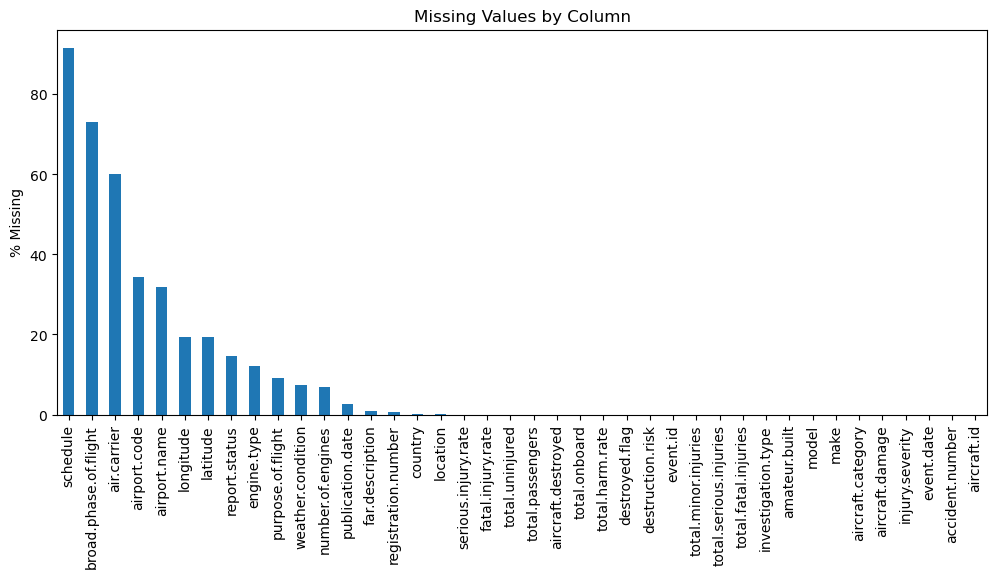

In [117]:
import matplotlib.pyplot as plt

(missing * 100).plot(kind="bar", figsize=(12,5))
plt.ylabel("% Missing")
plt.title("Missing Values by Column")
plt.show()

In [121]:
threshold = 0.60

cols_to_drop = missing[missing > threshold].index

df = df.drop(columns=cols_to_drop)


KeyError: "['schedule', 'broad.phase.of.flight'] not found in axis"

In [122]:
cols_to_drop

Index(['schedule', 'broad.phase.of.flight'], dtype='object')

In [123]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
Index: 19118 entries, 7 to 88886
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   event.id                19118 non-null  object        
 1   investigation.type      19118 non-null  object        
 2   accident.number         19118 non-null  object        
 3   event.date              19118 non-null  datetime64[ns]
 4   location                19115 non-null  object        
 5   country                 19112 non-null  object        
 6   latitude                15399 non-null  object        
 7   longitude               15395 non-null  object        
 8   airport.code            12548 non-null  object        
 9   airport.name            13020 non-null  object        
 10  injury.severity         19118 non-null  object        
 11  aircraft.damage         19118 non-null  object        
 12  aircraft.category       19118 non-null  object     

(19118, 38)

### Save DataFrame to csv
- its generally useful to save data to file/server after its in a sufficiently cleaned or intermediate state
- the data can then be loaded directly in another notebook for further analysis
- this helps keep your notebooks and workflow readable, clean and modularized

In [124]:
df.to_csv("Aviation_data_cleaned.csv", index=False)